# PRCP-1017-AutoPricePred

# importing necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

# Loading Dataset

In [2]:
df=pd.read_csv("auto_imports.csv",header= None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


**There are 201 rows and 26 columns.**

**As we can see that column names are not present in this dataset, but the name and the information about the column names are given in the documentation so we will assign the column names manually and accordingly.** 

In [4]:
columns = [
    "symboling", "normalized_losses", "make", "fuel_type", "aspiration",
    "num_of_doors", "body_style", "drive_wheels", "engine_location",
    "wheel_base", "length", "width", "height", "curb_weight",
    "engine_type", "num_of_cylinders", "engine_size", "fuel_system",
    "bore", "stroke", "compression_ratio", "horsepower",
    "peak_rpm", "city_mpg", "highway_mpg", "price"
]

df.columns = columns
pd.set_option("display.max_columns", None) # to get a display of all the columns

In [5]:
df.columns

Index(['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
       'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
       'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type',
       'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='object')

# Basic Checks

In [6]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel_type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num_of_doors       201 non-null    object 
 6   body_style         201 non-null    object 
 7   drive_wheels       201 non-null    object 
 8   engine_location    201 non-null    object 
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    object 
 15  num_of_cylinders   201 non-null    object 
 16  engine_size        201 non

In [8]:
  df.describe()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [9]:
df.describe(include=("O"))

,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,engine_type,num_of_cylinders,fuel_system,bore,stroke,horsepower,peak_rpm
count,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201
unique,52,22,2,2,3,5,3,2,6,7,8,39,37,59,23
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500
freq,37,32,181,165,113,94,118,198,145,157,92,23,19,19,36


- **df.info() shows several null values, but df.head() reveals that some missing values are represented as "?", so they need to be replaced with proper NaN values.**
- **Because of "?", many columns that should be numeric are currently stored as object datatype and need conversion after handling missing values.**
- **Some columns like num_of_doors have ordinal numeric meaning but are written in words (e.g., two, four), so they should be converted to numeric form.**
- **Overall, the dataset requires data cleaning, including handling missing values and correcting datatypes before analysis.**

# Data Cleaning

In [10]:
df.replace("?", np.nan, inplace=True) # it will replace all the "?" values with NaN.

In [11]:
df.isnull().sum()

symboling             0
normalized_losses    37
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

# Convert numeric columns to proper datatype

In [12]:
numeric_cols = [
    "normalized_losses","wheel_base","length","width","height",
    "curb_weight","engine_size","bore","stroke","compression_ratio",
    "horsepower","peak_rpm","city_mpg","highway_mpg","price"
]

df[numeric_cols] = df[numeric_cols].astype(float)


# Convert ordinal columns to numeric

### num_of_doors

In [13]:
door_map = {'two': 2, 'four': 4}
df['num_of_doors'] = df['num_of_doors'].map(door_map).astype(float)

### num_of_cylinders

In [14]:
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

df['num_of_cylinders'] = df['num_of_cylinders'].map(cylinder_map).astype(float)

### Handling missing values

In [15]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [16]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [17]:
df["num_of_doors"].fillna(df["num_of_doors"].mode()[0], inplace=True)

In [18]:
df.isnull().sum()

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64

In [19]:
df.reset_index(drop=True, inplace=True)

In [20]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,4.0,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,13495.0
1,3,115.0,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,48.8,2548.0,dohc,4.0,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,16500.0
2,1,115.0,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823.0,ohcv,6.0,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,16500.0
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,176.6,66.2,54.3,2337.0,ohc,4.0,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,13950.0
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,176.6,66.4,54.3,2824.0,ohc,5.0,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,17450.0


- **Missing values represented as "?" were successfully converted to proper NaN values, allowing accurate detection and handling of missing data.**
- **Several columns that were incorrectly stored as object datatype were converted to numeric types, enabling correct statistical analysis and model compatibility.**
- **Ordinal categorical features such as num_of_doors and num_of_cylinders were transformed into numeric format, improving their usefulness for analysis and machine learning.**
- **After handling missing values, duplicates, and datatype corrections, the dataset is now clean, consistent, and ready for exploratory data analysis and modeling.**

# Exploratory Data Analysis (EDA)

### Target Variable: Price

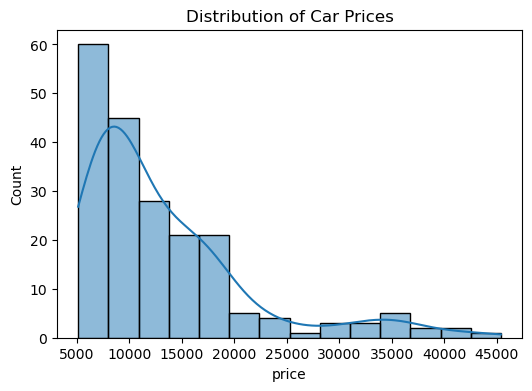

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.show()

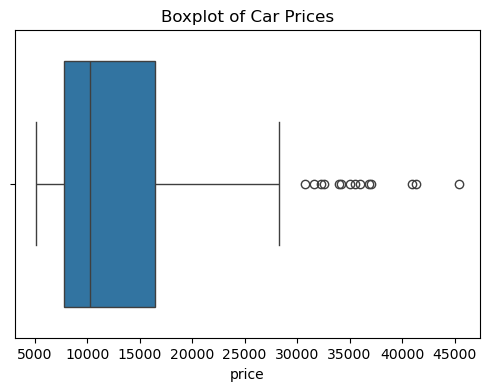

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Car Prices')
plt.show()

- **The car price distribution is right-skewed, with most cars priced between about 8,000 and 16,000 and a median around 10,000–11,000.**
- **Several high-price outliers above 30,000 indicate the presence of premium or luxury vehicles in the dataset.**

## make vs price

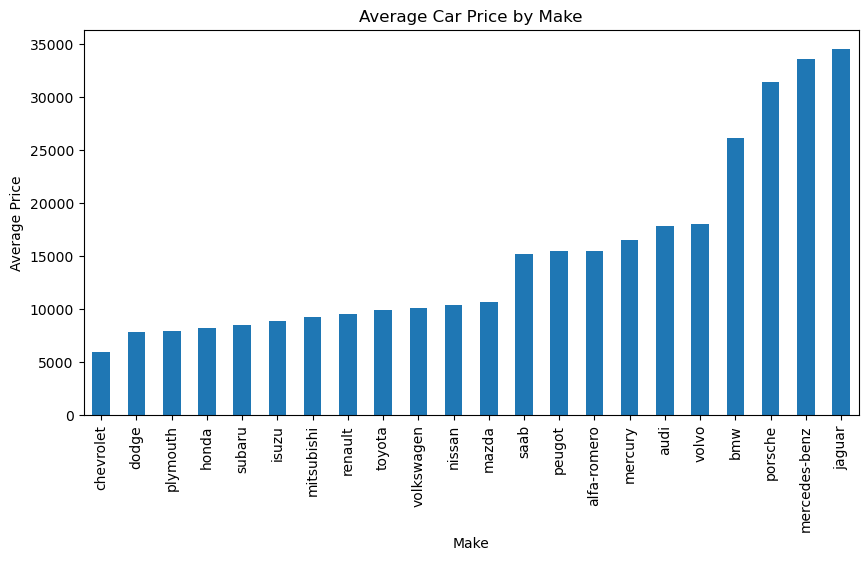

In [23]:
# Calculate average price per make
make_price = df.groupby("make")["price"].mean().sort_values()


plt.figure(figsize=(10,5))
make_price.plot(kind="bar")
plt.title("Average Car Price by Make")
plt.xlabel("Make")
plt.ylabel("Average Price")
plt.xticks(rotation=90)
plt.show()


<Figure size 1200x600 with 0 Axes>

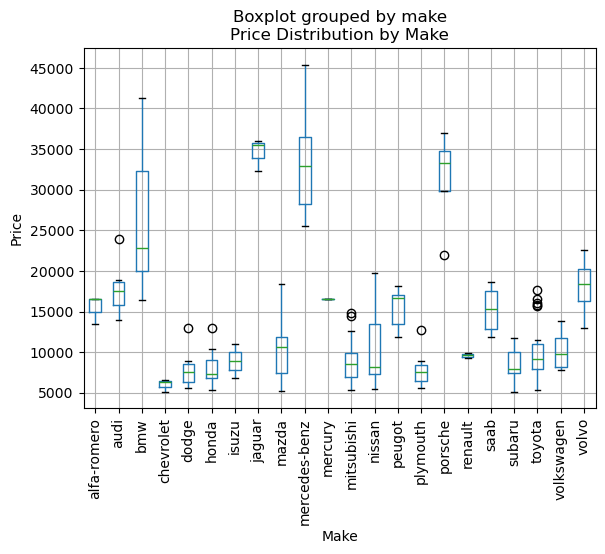

In [24]:
plt.figure(figsize=(12,6))
df.boxplot(column="price", by="make", rot=90)
plt.title("Price Distribution by Make")
plt.xlabel("Make")
plt.ylabel("Price")
plt.show()

- **Luxury brands like Jaguar, Mercedes-Benz, Porsche, BMW have the highest average prices.**
- **Mid-range brands like Audi, Volvo, Mercury, Saab fall in the middle price segment.**
- **Economy brands like Chevrolet, Dodge, Plymouth, Honda have lower average prices.**

## fuel_type vs price

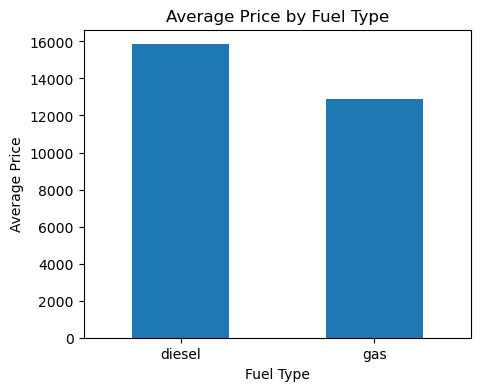

fuel_type
diesel    15838.15000
gas       12916.40884
Name: price, dtype: float64

In [25]:
fuel_price = df.groupby("fuel_type")["price"].mean()

plt.figure(figsize=(5,4))
fuel_price.plot(kind="bar")
plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.show()

fuel_price


<Figure size 500x400 with 0 Axes>

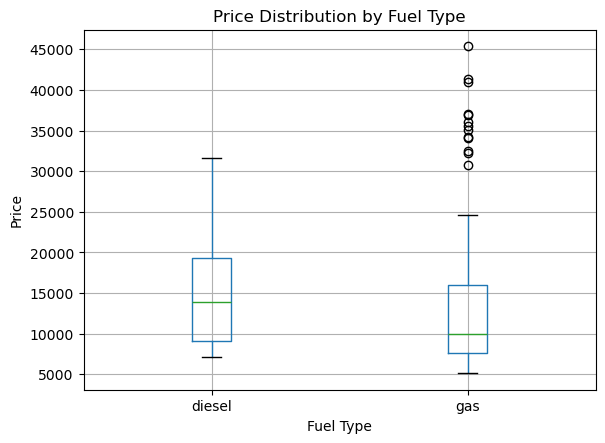

In [26]:
plt.figure(figsize=(5,4))
df.boxplot(column="price", by="fuel_type")
plt.title("Price Distribution by Fuel Type")
plt.suptitle("")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()


- **Diesel cars have higher average prices than gas cars.**
- **This suggests diesel vehicles may have better mileage, durability, or premium positioning.**

## aspiration vs price

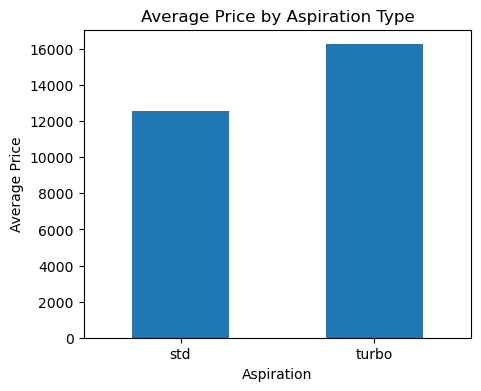

aspiration
std      12542.181818
turbo    16254.805556
Name: price, dtype: float64

In [27]:
asp_price = df.groupby("aspiration")["price"].mean()

plt.figure(figsize=(5,4))
asp_price.plot(kind="bar")
plt.title("Average Price by Aspiration Type")
plt.xlabel("Aspiration")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.show()

asp_price


- Turbo cars are significantly more expensive than standard (std) cars.
- Turbo engines provide higher performance, which increases price.

## num_of_doors vs Price

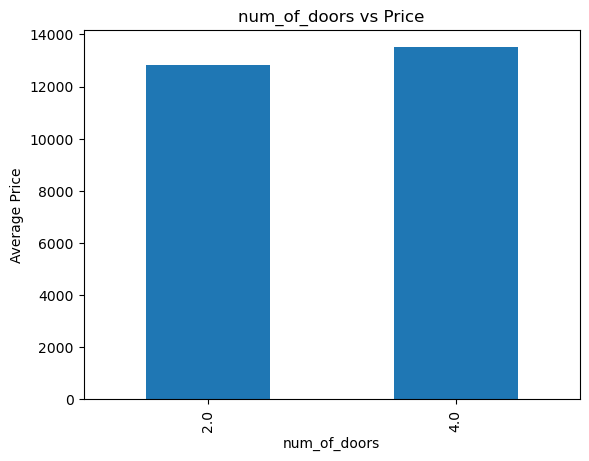

In [28]:
df.groupby("num_of_doors")["price"].mean().plot(kind="bar", title="num_of_doors vs Price")
plt.ylabel("Average Price")
plt.show()

- **Cars with 4 doors are slightly more expensive than 2-door cars.**
- **Difference is small, indicating weak correlation.**

## body_style vs Price

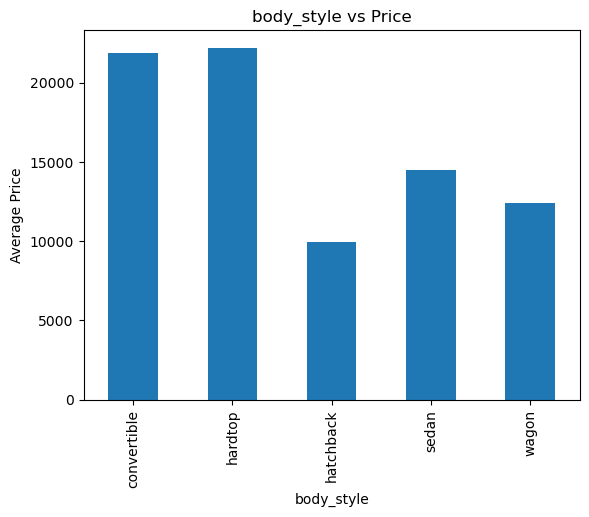

In [29]:
df.groupby("body_style")["price"].mean().plot(kind="bar", title="body_style vs Price")
plt.ylabel("Average Price")
plt.show()

- **Convertibles and hardtops have the highest average prices.**
- **Hatchbacks are the cheapest body style.**
- **Sedans and wagons fall in the mid-range.**

## drive_wheels vs Price

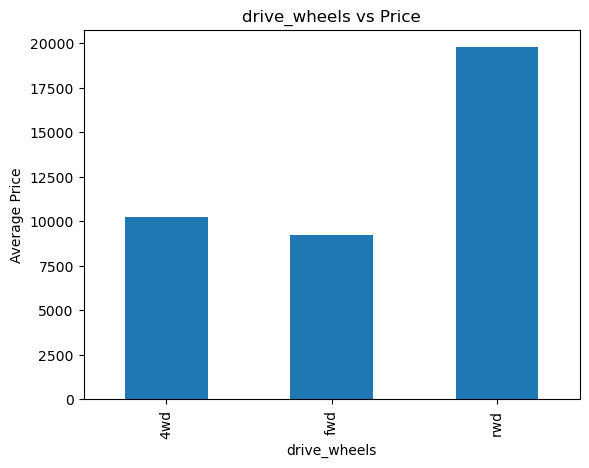

In [30]:
df.groupby("drive_wheels")["price"].mean().plot(kind="bar", title="drive_wheels vs Price")
plt.ylabel("Average Price")
plt.show()

- **Rear wheel drive (RWD) cars are the most expensive.**
- **4WD is mid-range.**
- **Front wheel drive (FWD) cars are cheapest.**

## engine_location vs Price

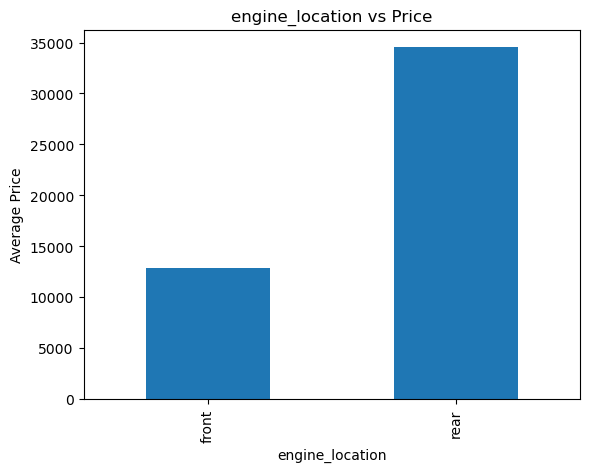

In [31]:
df.groupby("engine_location")["price"].mean().plot(kind="bar", title="engine_location vs Price")
plt.ylabel("Average Price")
plt.show()

- **Rear engine cars are significantly more expensive than front engine cars.**
- **Rear engine configuration is rare and usually found in sports/luxury cars.**

## wheel_base vs Price

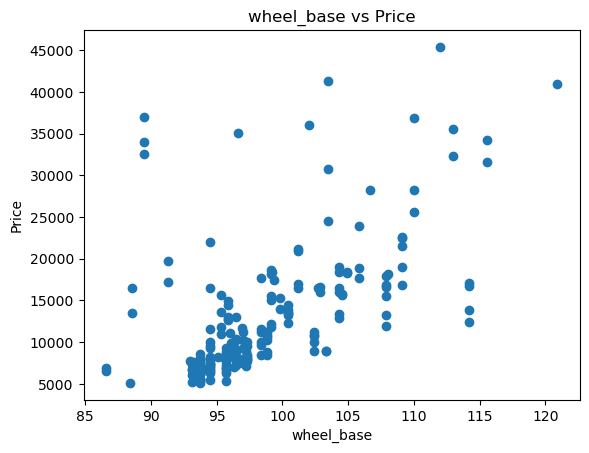

In [32]:
plt.scatter(df["wheel_base"], df["price"])
plt.title("wheel_base vs Price")
plt.xlabel("wheel_base")
plt.ylabel("Price")
plt.show()

- **Positive relationship between wheel base and price.**
- **Cars with larger wheelbase tend to be more expensive.**
- **Some spread indicates moderate correlation.**

## length vs Price

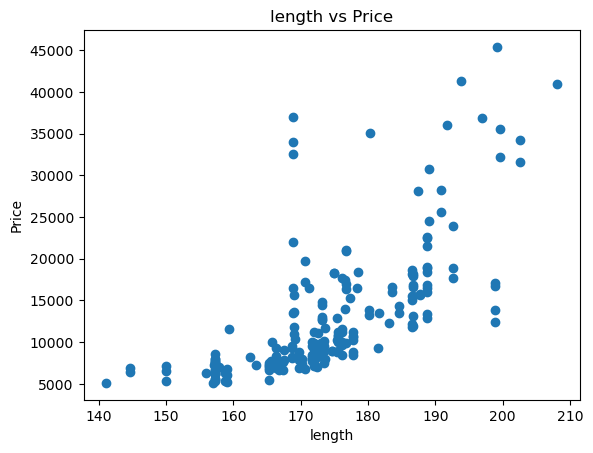

In [33]:
plt.scatter(df["length"], df["price"])
plt.title("length vs Price")
plt.xlabel("length")
plt.ylabel("Price")
plt.show()

- **Strong positive trend — longer cars generally cost more.**
- **Higher price range concentrated at larger lengths.**
- **Indicates vehicle size strongly impacts price.**

## width vs Price

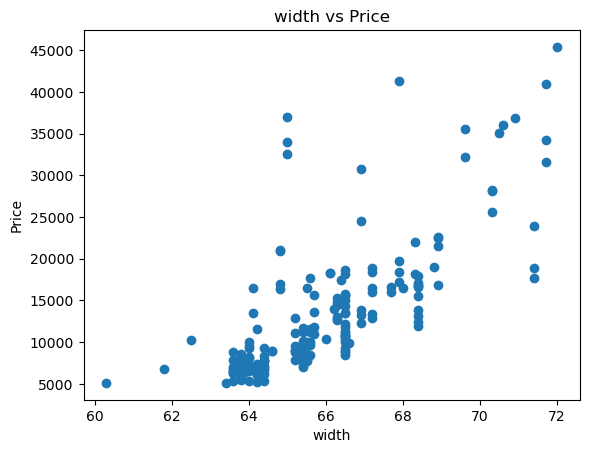

In [34]:
plt.scatter(df["width"], df["price"])
plt.title("width vs Price")
plt.xlabel("width")
plt.ylabel("Price")
plt.show()

- **There is a positive relationship between width and price.**
- **Cars with larger width generally tend to be more expensive.**
- **However, the spread of points shows moderate correlation with some variability.**
- **A few high-price outliers exist at higher widths.**

## height vs Price

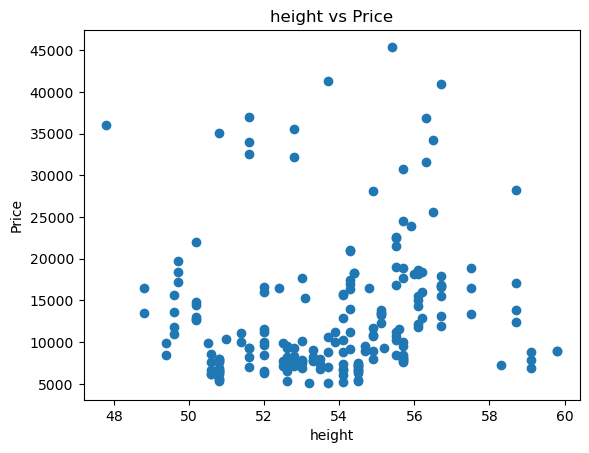

In [35]:
plt.scatter(df["height"], df["price"])
plt.title("height vs Price")
plt.xlabel("height")
plt.ylabel("Price")
plt.show()

- The scatter plot shows a weak relationship between height and price.
- Prices vary widely across similar height values.
- No clear upward or downward trend is visible.
- This indicates height is not a strong predictor of car price.

## curb_weight vs Price

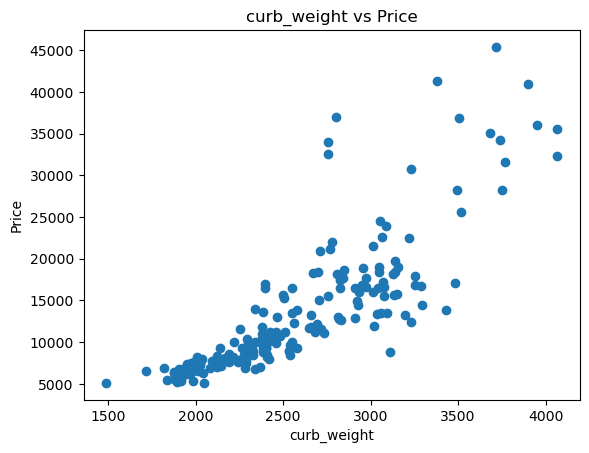

In [36]:
plt.scatter(df["curb_weight"], df["price"])
plt.title("curb_weight vs Price")
plt.xlabel("curb_weight")
plt.ylabel("Price")
plt.show()

- There is a strong positive correlation between curb weight and price.
- As curb weight increases, price also increases.
- The points follow a clear upward trend.
- Indicates curb weight is a very important feature for price prediction.

## engine_type vs Price

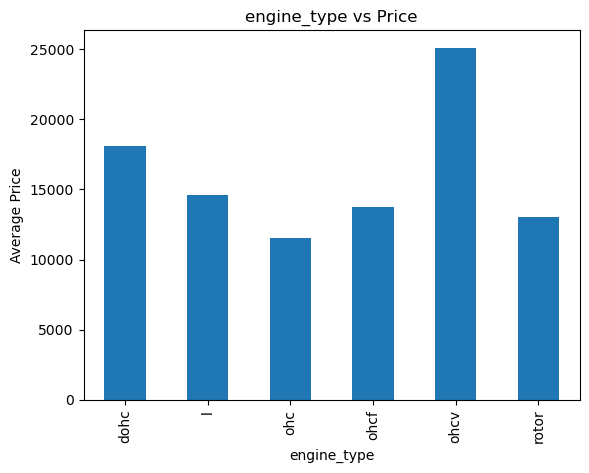

In [37]:
df.groupby("engine_type")["price"].mean().plot(kind="bar", title="engine_type vs Price")
plt.ylabel("Average Price")
plt.show()

- Average price varies significantly across engine types.
- ohcv engines have the highest average price.
- ohc engines have relatively lower average prices.
- Shows engine configuration impacts vehicle pricing.

## num_of_cylinders vs Price

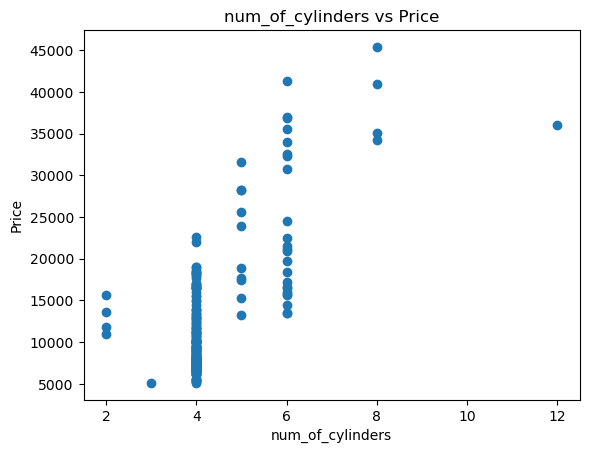

In [38]:
plt.scatter(df["num_of_cylinders"], df["price"])
plt.title("num_of_cylinders vs Price")
plt.xlabel("num_of_cylinders")
plt.ylabel("Price")
plt.show()

- There is a positive relationship between number of cylinders and price.
- Cars with more cylinders (6, 8, 12) generally have higher prices.
- Most cars have 4 cylinders and fall in the lower to mid price range.
- Indicates engine power influences price.

## engine_size vs Price

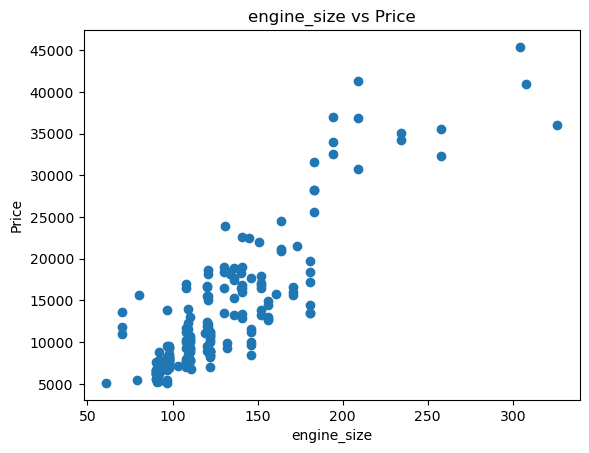

In [39]:
plt.scatter(df["engine_size"], df["price"])
plt.title("engine_size vs Price")
plt.xlabel("engine_size")
plt.ylabel("Price")
plt.show()

**There is a strong positive linear correlation between engine size and price. As the engine size increases, the price of the vehicle tends to rise significantly. This suggests that engine size is one of the most reliable predictors for a car's market value.**

## fuel_system vs Price

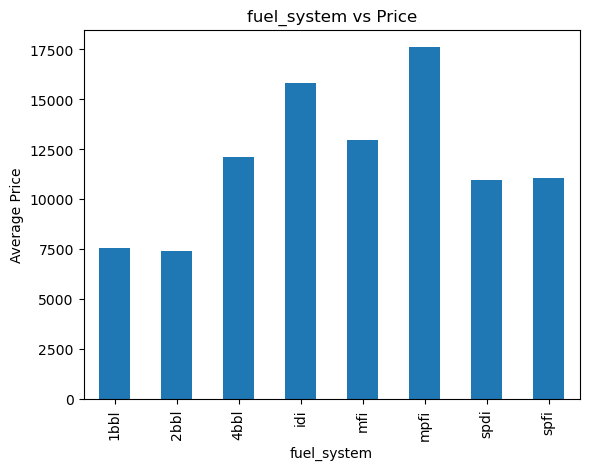

In [40]:
df.groupby("fuel_system")["price"].mean().plot(kind="bar", title="fuel_system vs Price")
plt.ylabel("Average Price")
plt.show()

- Different fuel systems show noticeable differences in average price.
- mpfi fuel system has the highest average price.
- 1bbl and 2bbl have the lowest average prices.
- Indicates fuel delivery technology affects car price.

## bore vs Price

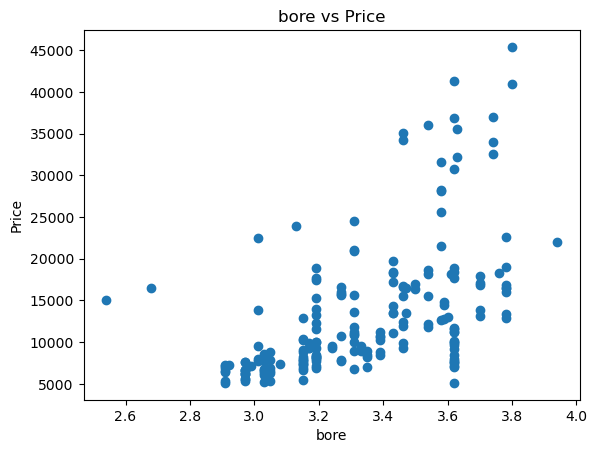

In [41]:
plt.scatter(df["bore"], df["price"])
plt.title("bore vs Price")
plt.xlabel("bore")
plt.ylabel("Price")
plt.show()

**There is a moderate positive correlation between the bore (diameter of the cylinder) and the price. While larger bores generally point toward more expensive, larger engines, the spread of the data indicates that bore size alone is a less precise predictor of price compared to total engine displacement.**

## stroke vs Price

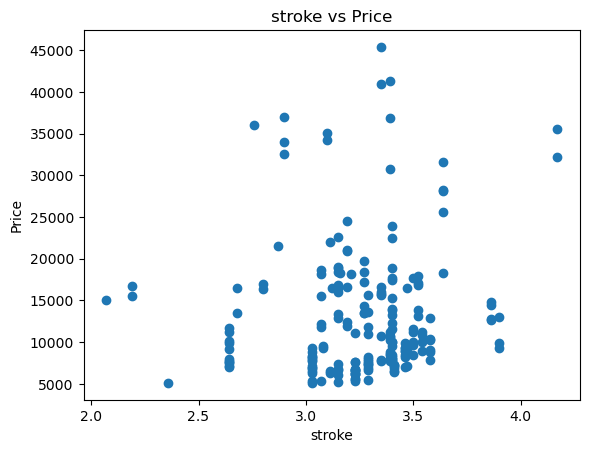

In [42]:
plt.scatter(df["stroke"], df["price"])
plt.title("stroke vs Price")
plt.xlabel("stroke")
plt.ylabel("Price")
plt.show()

**The relationship between stroke and price is weak. The data points are scattered with significant vertical overlapping (e.g., many cars with a stroke of 3.4 vary wildly in price). This suggests that stroke length is not a primary driver of vehicle cost in this dataset.**

## horsepower vs Price

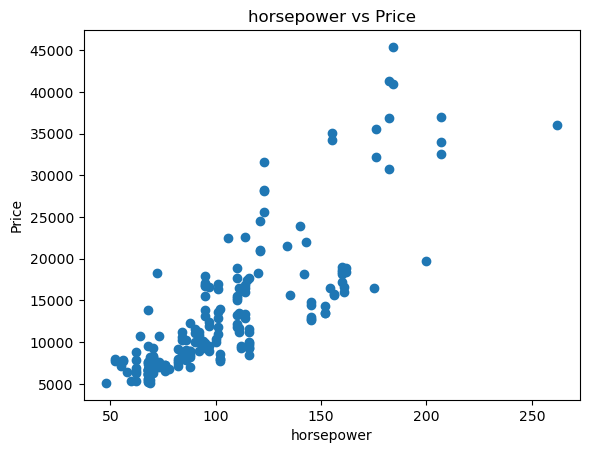

In [43]:
plt.scatter(df["horsepower"], df["price"])
plt.title("horsepower vs Price")
plt.xlabel("horsepower")
plt.ylabel("Price")
plt.show()

**horsepower shows a strong positive correlation with price. The data points follow an upward trend, indicating that consumers pay a premium for higher power output. There is some variance at the higher end (above 150 HP), suggesting other luxury factors may influence the price in that bracket.**

## peak_rpm vs Price

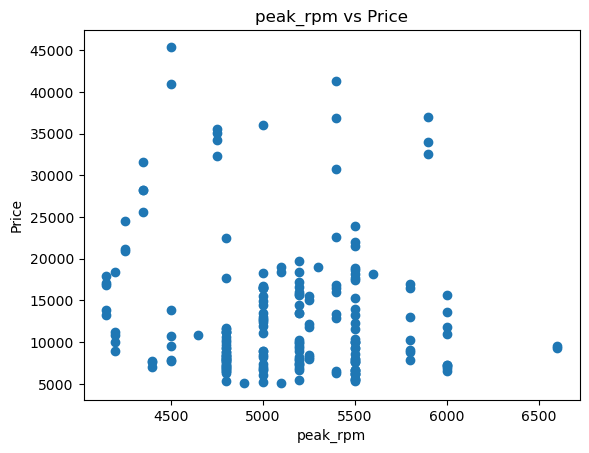

In [44]:
plt.scatter(df["peak_rpm"], df["price"])
plt.title("peak_rpm vs Price")
plt.xlabel("peak_rpm")
plt.ylabel("Price")
plt.show()

**There is almost no correlation between peak RPM and price. The scatter plot shows a "cloud" pattern where expensive and inexpensive cars are distributed across the same RPM ranges. High-revving engines are found in both economy and luxury tiers, making this a poor predictor for price.**

## city_mpg vs Price

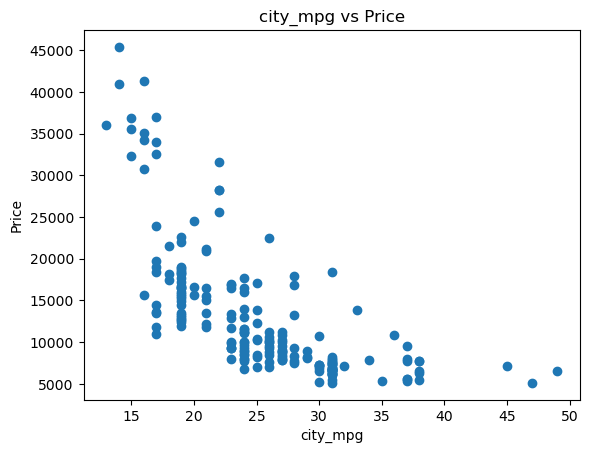

In [45]:
plt.scatter(df["city_mpg"], df["price"])
plt.title("city_mpg vs Price")
plt.xlabel("city_mpg")
plt.ylabel("Price")
plt.show()

## highway_mpg vs Price

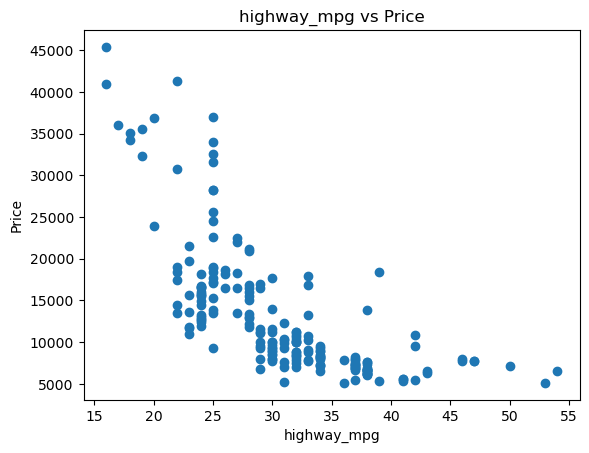

In [46]:
plt.scatter(df["highway_mpg"], df["price"])
plt.title("highway_mpg vs Price")
plt.xlabel("highway_mpg")
plt.ylabel("Price")
plt.show()

**Both city_mpg and highway_mpg exhibit a strong negative correlation with price. This relationship is non-linear; as fuel efficiency (MPG) increases, the price typically drops. This reflects the market distinction between expensive, high-performance/luxury vehicles (low MPG) and budget-friendly economy cars (high MPG).**

## correlation matrix

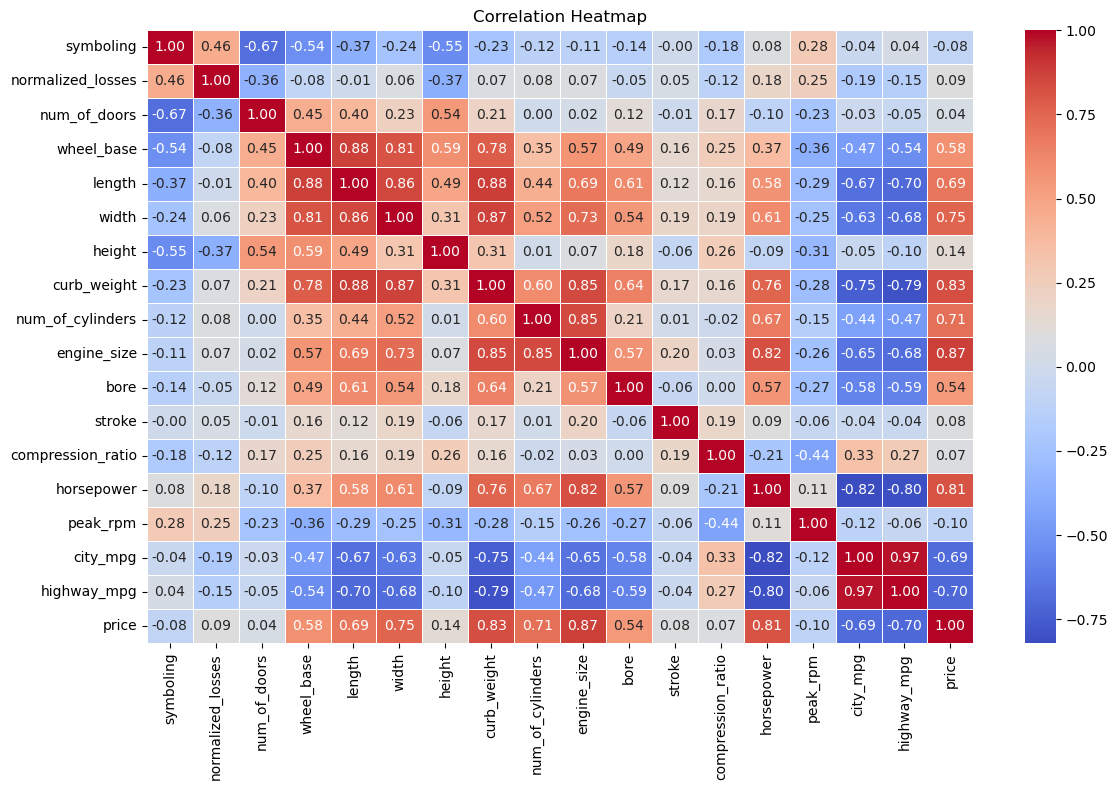

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**The correlation analysis shows that engine size, curb weight, horsepower, and car dimensions have strong positive relationships with price, while fuel efficiency features such as city and highway mpg show strong negative relationships. Several features exhibit multicollinearity, particularly among engine and size-related variables, indicating that tree-based models like XGBoost are more suitable for this dataset.**

In [48]:
# Correlation with target
corr_with_price = df.corr(numeric_only=True)["price"].sort_values(ascending=False)

corr_with_price


price                1.000000
engine_size          0.872335
curb_weight          0.834415
horsepower           0.810500
width                0.751265
num_of_cylinders     0.708645
length               0.690628
wheel_base           0.584642
bore                 0.543158
height               0.135486
normalized_losses    0.094366
stroke               0.082209
compression_ratio    0.071107
num_of_doors         0.042435
symboling           -0.082391
peak_rpm            -0.102310
city_mpg            -0.686571
highway_mpg         -0.704692
Name: price, dtype: float64

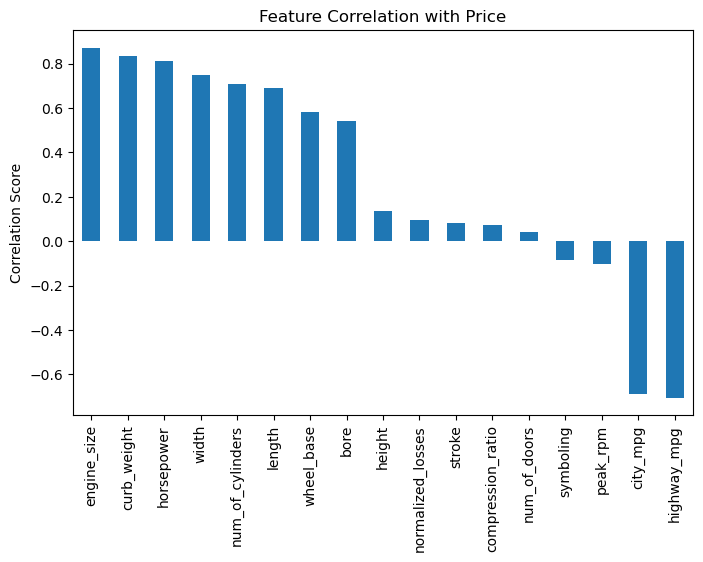

In [49]:
corr_with_price.drop("price").plot(kind="bar", figsize=(8,5))
plt.title("Feature Correlation with Price")
plt.ylabel("Correlation Score")
plt.show()


# Feature Engineering

## **Features to be Scaled**
**Features requiring scaling (continuous numerical variables)**
- engine_size
- curb_weight
- horsepower
- width
- length
- wheel_base
- bore
- city_mpg
- highway_mpg
- height
- normalized_losses

## **Ordinal Encoding**
- num_of_cylinders → already numeric

## **One-Hot Encoding**
**Categorical variables like:**
- make
- fuel_type
- aspiration
- body_style
- drive_wheels
- engine_type
- fuel_system

## **Features Excluded from Modeling**
**The following features were removed due to weak relationship with price or low predictive value:**
- stroke
- compression_ratio
- num_of_doors
- symboling
- peak_rpm

**these variables have very low absolute correlation (< 0.1), indicating minimal influence on price prediction.**

## Dropping Redundant Features

In [50]:
drop_cols = [
    "stroke",
    "compression_ratio",
    "num_of_doors",
    "symboling",
    "peak_rpm" 
]

df.drop(columns=drop_cols, inplace=True)


In [51]:
cat_cols = df.select_dtypes(include="object").columns

## One-Hot Encoding

In [52]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded.head()

,normalized_losses,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,horsepower,city_mpg,highway_mpg,price,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,make_mitsubishi,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo,fuel_type_gas,aspiration_turbo,body_style_hardtop,body_style_hatchback,body_style_sedan,body_style_wagon,drive_wheels_fwd,drive_wheels_rwd,engine_location_rear,engine_type_l,engine_type_ohc,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,115.0,88.6,168.8,64.1,48.8,2548.0,4.0,130.0,3.47,111.0,21.0,27.0,13495.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
1,115.0,88.6,168.8,64.1,48.8,2548.0,4.0,130.0,3.47,111.0,21.0,27.0,16500.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
2,115.0,94.5,171.2,65.5,52.4,2823.0,6.0,152.0,2.68,154.0,19.0,26.0,16500.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False
3,164.0,99.8,176.6,66.2,54.3,2337.0,4.0,109.0,3.19,102.0,24.0,30.0,13950.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,164.0,99.4,176.6,66.4,54.3,2824.0,5.0,136.0,3.19,115.0,18.0,22.0,17450.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False


# Feature separation

In [53]:
X = df_encoded.drop('price', axis=1)
Y = df_encoded['price']

In [54]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = num_cols.drop('price')


# train_test_split

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# outlier handling

* Outlier handling was tested using the IQR capping method, but model performance decreased after treatment, with lower R² and higher error values. This indicates that the extreme values were genuine high-priced vehicles rather than noise or data errors. In price prediction problems, such variations naturally occur due to features like engine size, brand, and horsepower. Therefore, removing or capping outliers was avoided to preserve meaningful data patterns and maintain better model performance.

## Applying StandardScaler

In [56]:
from sklearn.preprocessing import StandardScaler
# Scale only numerical columns
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols]) 

In [57]:
X_train[num_cols].describe()

,normalized_losses,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,horsepower,city_mpg,highway_mpg
count,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02,1.600000e+02
mean,8.049117e-17,1.348921e-15,-1.687539e-15,1.865175e-15,-1.906808e-15,1.748601e-16,3.441691e-16,2.220446e-17,-1.010303e-15,-1.554312e-16,1.054712e-16,-1.110223e-16
std,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00,1.003140e+00
min,-1.698807e+00,-2.061908e+00,-2.744218e+00,-2.738386e+00,-2.463339e+00,-2.144340e+00,-2.244613e+00,-1.606962e+00,-2.877059e+00,-1.509353e+00,-1.949426e+00,-2.214171e+00
25%,-5.916414e-01,-7.221396e-01,-6.021453e-01,-8.588576e-01,-7.498892e-01,-7.111772e-01,-3.085587e-01,-6.733785e-01,-6.385310e-01,-8.922174e-01,-8.790753e-01,-8.648667e-01
50%,-1.610772e-01,-3.066417e-01,-6.871093e-02,-1.493665e-01,1.068356e-01,-2.497711e-01,-3.085587e-01,-3.579787e-01,-5.137606e-02,-1.909264e-01,-1.258653e-01,-1.152531e-01
75%,5.155238e-01,6.176292e-01,7.647802e-01,3.609691e-01,6.881846e-01,7.928537e-01,-3.085587e-01,4.115967e-01,9.761451e-01,3.771192e-01,7.462725e-01,4.844378e-01
max,4.175320e+00,3.755062e+00,2.840173e+00,3.086908e+00,2.432232e+00,3.113140e+00,7.435659e+00,5.079513e+00,2.260547e+00,4.493697e+00,3.759112e+00,3.482892e+00


In [58]:
X_train[num_cols].shape

(160, 12)

In [59]:
X_test[num_cols].shape

(41, 12)

In [60]:
X_train[num_cols].isnull().sum()

normalized_losses    0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
num_of_cylinders     0
engine_size          0
bore                 0
horsepower           0
city_mpg             0
highway_mpg          0
dtype: int64

In [61]:
X_test[num_cols].isnull().sum()

normalized_losses    0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
num_of_cylinders     0
engine_size          0
bore                 0
horsepower           0
city_mpg             0
highway_mpg          0
dtype: int64

# model building

## LinearRegression

In [62]:
from sklearn.linear_model import LinearRegression

le_model = LinearRegression()
le_model.fit(X_train[num_cols] , Y_train)


LinearRegression()

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_train_pred1 = le_model.predict(X_train[num_cols])
y_test_pred1 = le_model.predict(X_test[num_cols])

print("🔹 Linear REGRESSION PERFORMANCE")

print("\nTRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred1))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred1)))
print("R2 Score:", r2_score(Y_train, y_train_pred1))

print("\nTEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred1))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred1)))
print("R2 Score:", r2_score(Y_test, y_test_pred1))


🔹 Linear REGRESSION PERFORMANCE

TRAINING PERFORMANCE
MAE: 1998.812140846066
RMSE: 2773.931740994863
R2 Score: 0.831354028091589

TEST PERFORMANCE
MAE: 3797.0086904286673
RMSE: 5503.805256090255
R2 Score: 0.7524097159759682


## Ridge Regression

In [64]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

# Train model
ridge.fit(X_train[num_cols], Y_train)

# Predictions
y_train_pred6 = ridge.predict(X_train[num_cols])
y_test_pred6 = ridge.predict(X_test[num_cols])

# Evaluation
print("🔹 RIDGE REGRESSION PERFORMANCE")

print("\nTRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred6))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred6)))
print("R2 Score:", r2_score(Y_train, y_train_pred6))

print("\nTEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred6))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred6)))
print("R2 Score:", r2_score(Y_test, y_test_pred6))


🔹 RIDGE REGRESSION PERFORMANCE

TRAINING PERFORMANCE
MAE: 1986.1329615172522
RMSE: 2775.09421222192
R2 Score: 0.8312126495814333

TEST PERFORMANCE
MAE: 3810.283245568236
RMSE: 5521.53262040749
R2 Score: 0.7508122060757667


## Lasso Regression

In [65]:
from sklearn.linear_model import Lasso

# Initialize model
lasso = Lasso(alpha=0.1)

# Train model
lasso.fit(X_train[num_cols], Y_train)

# Predictions
y_train_pred7 = lasso.predict(X_train[num_cols])
y_test_pred7 = lasso.predict(X_test[num_cols])

# Evaluation
print("🔹 LASSO REGRESSION PERFORMANCE")

print("\nTRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred7))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred7)))
print("R2 Score:", r2_score(Y_train, y_train_pred7))

print("\nTEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred7))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred7)))
print("R2 Score:", r2_score(Y_test, y_test_pred7))


🔹 LASSO REGRESSION PERFORMANCE

TRAINING PERFORMANCE
MAE: 1998.6659706918206
RMSE: 2773.932028579531
R2 Score: 0.8313539931231738

TEST PERFORMANCE
MAE: 3797.2846621648246
RMSE: 5504.115559423106
R2 Score: 0.7523817970171697


## RandomForest

In [66]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [67]:
y_train_pred8 = rf_model.predict(X_train)
y_test_pred8 = rf_model.predict(X_test)

In [68]:
# Training Performance
print("🔹 RANDOM FOREST TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred8))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred8)))
print("R2 Score:", r2_score(Y_train, y_train_pred8))

print("\n")

# Test Performance 
print("🔹 RANDOM FOREST TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred8))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred8)))
print("R2 Score:", r2_score(Y_test, y_test_pred8))

🔹 RANDOM FOREST TRAINING PERFORMANCE
MAE: 576.6369770833332
RMSE: 851.1202700779602
R2 Score: 0.9841230784142719


🔹 RANDOM FOREST TEST PERFORMANCE
MAE: 1870.28756504065
RMSE: 2898.777515458835
R2 Score: 0.9313188989590225


## GradientBoosting

In [69]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,      # number of trees
    learning_rate=0.05,    # step size
    max_depth=3,           # tree depth
    random_state=42
)

gb_model.fit(X_train, Y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [70]:
y_train_pred2 = gb_model.predict(X_train)
y_test_pred2 = gb_model.predict(X_test)

In [71]:
# Training Performance
print("🔹 GradientBoosting TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred2))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred2)))
print("R2 Score:", r2_score(Y_train, y_train_pred2))

print("\n")

# Test Performance 
print("🔹GradientBoosting TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred2))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred2)))
print("R2 Score:", r2_score(Y_test, y_test_pred2))

🔹 GradientBoosting TRAINING PERFORMANCE
MAE: 485.18276172545427
RMSE: 648.5178712295886
R2 Score: 0.9907821777470438


🔹GradientBoosting TEST PERFORMANCE
MAE: 1674.2630660897557
RMSE: 2613.089141143735
R2 Score: 0.944189497707893


## xgboost

In [72]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=300,        
    learning_rate=0.05,      
    max_depth=4,             
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [73]:
y_train_pred3 = xgb_model.predict(X_train)
y_test_pred3 = xgb_model.predict(X_test)

In [74]:
# Training Performance
print("🔹 xgboost TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred3))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred3)))
print("R2 Score:", r2_score(Y_train, y_train_pred3))

print("\n")

# Test Performance 
print("🔹xgboost TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred3))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred3)))
print("R2 Score:", r2_score(Y_test, y_test_pred3))

🔹 xgboost TRAINING PERFORMANCE
MAE: 293.2976806640625
RMSE: 403.8298999664234
R2 Score: 0.9964257792212934


🔹xgboost TEST PERFORMANCE
MAE: 1552.3977824885671
RMSE: 2392.844449901617
R2 Score: 0.9532010169360559


## SVR

In [75]:
from sklearn.svm import SVR

svm_model = SVR(
    kernel='rbf',     
    C=100,            
    epsilon=0.1,
    gamma='scale'
)

svm_model.fit(X_train[num_cols], Y_train)

SVR(C=100)

In [76]:
y_train_pred4 = svm_model.predict(X_train[num_cols])
y_test_pred4 = svm_model.predict(X_test[num_cols])

In [77]:
# Training Performance
print("🔹 SVR TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred4))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred4)))
print("R2 Score:", r2_score(Y_train, y_train_pred4))

print("\n")

# Test Performance 
print("🔹SVR TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred4))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred4)))
print("R2 Score:", r2_score(Y_test, y_test_pred4))

🔹 SVR TRAINING PERFORMANCE
MAE: 3372.113340987122
RMSE: 6012.881280011828
R2 Score: 0.20759046875054488


🔹SVR TEST PERFORMANCE
MAE: 6676.2612481100805
RMSE: 11140.957645109389
R2 Score: -0.014501111249034526


## DecisionTreeRegressor

In [78]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,          
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [79]:
y_train_pred5 = dt_model.predict(X_train)
y_test_pred5 = dt_model.predict(X_test)

In [80]:
# Training Performance
print("🔹  DecisionTree TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred5))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred5)))
print("R2 Score:", r2_score(Y_train, y_train_pred5))

print("\n")

# Test Performance 
print("🔹DecisionTree TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred5))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred5)))
print("R2 Score:", r2_score(Y_test, y_test_pred5))

🔹  DecisionTree TRAINING PERFORMANCE
MAE: 1044.7436794510315
RMSE: 1477.9304766255664
R2 Score: 0.9521268017498069


🔹DecisionTree TEST PERFORMANCE
MAE: 1859.7054098661288
RMSE: 2806.038066816393
R2 Score: 0.9356431768976768


- Multiple regression models were trained and evaluated using MAE, RMSE, and R² score.
- Tree-based ensemble models significantly outperformed linear models due to their ability to capture nonlinear relationships.
- XGBoost achieved the highest test R² score and lowest prediction errors, indicating superior generalization performance.
- Therefore, XGBoost was selected as the final model for car price prediction.**

## Hyper parameter Tuning

## xgboost

In [81]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

In [82]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5]
}


In [83]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,              # number of combinations to try
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [84]:
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [85]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}


In [86]:
best_xgb = random_search.best_estimator_

y_train_pred9 = best_xgb.predict(X_train)
y_test_pred9 = best_xgb.predict(X_test)


In [87]:
# Training Performance
print("🔹 best_xgb TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred9))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred9)))
print("R2 Score:", r2_score(Y_train, y_train_pred9))

print("\n") 

# Test Performance 
print("🔹best_xgb TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred9))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred9)))
print("R2 Score:", r2_score(Y_test, y_test_pred9))

🔹 best_xgb TRAINING PERFORMANCE
MAE: 519.7556274414062
RMSE: 842.0641458620202
R2 Score: 0.9844591494356024


🔹best_xgb TEST PERFORMANCE
MAE: 1526.6080173399391
RMSE: 2392.776259219442
R2 Score: 0.9532036842294593


## GradientBoosting

In [88]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

gbr = GradientBoostingRegressor(random_state=42)

In [89]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

In [90]:
random_search_gb = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [91]:
random_search_gb.fit(X_train, Y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [92]:
print("Best Parameters:", random_search_gb.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 2, 'learning_rate': 0.05}


In [93]:
best_gb = random_search_gb.best_estimator_

y_train_pred10 = best_gb.predict(X_train)
y_test_pred10 = best_gb.predict(X_test)

In [94]:
# Training Performance
print("🔹 best_gb TRAINING PERFORMANCE")
print("MAE:", mean_absolute_error(Y_train, y_train_pred10))
print("RMSE:", np.sqrt(mean_squared_error(Y_train, y_train_pred10)))
print("R2 Score:", r2_score(Y_train, y_train_pred10))

print("\n") 

# Test Performance 
print("🔹best_gb TEST PERFORMANCE")
print("MAE:", mean_absolute_error(Y_test, y_test_pred10))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_test_pred10)))
print("R2 Score:", r2_score(Y_test, y_test_pred10))

🔹 best_gb TRAINING PERFORMANCE
MAE: 782.4598780841095
RMSE: 1060.8309429172834
R2 Score: 0.9753352458761086


🔹best_gb TEST PERFORMANCE
MAE: 1585.7813818797085
RMSE: 2508.9053698174025
R2 Score: 0.9485511060398435


**After hyperparameter tuning, both XGBoost and Gradient Boosting models achieved strong predictive performance. However, XGBoost slightly outperformed Gradient Boosting with a higher test R² score of 0.9532 and lower error metrics, indicating better accuracy and generalization. Therefore, XGBoost is selected as the final model for deployment as it provides the most reliable predictions.**

# 🚗 Auto Price Prediction Report

---

## 📌 1. Objective

The objective of this project is to analyze the automobile dataset and build a predictive model that accurately estimates car prices based on various independent variables.

This helps management understand the key factors influencing price variation and supports data-driven decision making.

---

# 🔎 2. Challenges Faced & Techniques Used

---

## 1️⃣ Missing Values

**Challenge:**
Some features contained missing or unknown values which could reduce model accuracy and lead to biased analysis.

**Techniques Used:**

* Median/Mean imputation for numerical features
* Mode imputation for categorical features
* Dropped rows only where necessary

---

## 2️⃣ Multicollinearity Between Features

**Challenge:**
Highly correlated variables such as engine_size, horsepower, curb_weight, and mileage can affect linear model stability.

**Techniques Used:**

* Correlation heatmap analysis
* Feature selection based on correlation strength
* Dropped redundant features when required

---

## 3️⃣ Categorical Variables Not Suitable for ML Models

**Challenge:**
Dataset contains categorical features like make, fuel_type, body_style, drive_wheels which cannot be directly used in ML models.

**Techniques Used:**

* One-Hot Encoding using `get_dummies()`
* Dropped first category to avoid dummy variable trap

---

## 4️⃣ Different Feature Scales

**Challenge:**
Numerical features had different ranges (e.g., engine size vs mpg), affecting models like Linear Regression and SVR.

**Techniques Used:**

* Standardization using `StandardScaler`
* Scaling applied after train-test split

---

## 5️⃣ Risk of Overfitting

**Challenge:**
Complex models like Random Forest and Boosting showed very high training accuracy.

**Techniques Used:**

* Compared training vs testing performance
* Applied hyperparameter tuning
* Evaluated generalization ability

---

## 6️⃣ Model Selection Difficulty

**Challenge:**
Different algorithms performed differently, making selection difficult.

**Technique Used:**

* Built multiple models
* Compared using MAE, RMSE, and R²

---

# 🤖 3. Models Evaluated

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting Regressor
* XGBoost Regressor
* Support Vector Regressor (SVR)

---

# 📊 4. Evaluation Metrics

The following metrics were used to evaluate model performance:

* **MAE (Mean Absolute Error)**
* **RMSE (Root Mean Squared Error)**
* **R² Score (Coefficient of Determination)**

---

# 📈 5. Model Performance Summary & Interpretation

---

## 🔹 1. Linear Regression

**Training Performance**

- **MAE:** 1998.81

- **RMSE:** 2773.93

- **R² Score:** 0.831

**Test Performance**

- **MAE:** 3797.01

- **RMSE:** 5503.81

- **R² Score:** 0.752

**Interpretation:**
Linear Regression explains about 75% of the variance in car prices on test data. The noticeable increase in error from training to testing indicates the model cannot fully capture nonlinear relationships, making it suitable only as a baseline model.

---

## 🔹 2. Ridge Regression
**Training Performance**

- **MAE:** 1986.13

- **RMSE:** 2775.09

- **R² Score:** 0.831

**Test Performance**

- **MAE:** 3810.28

- **RMSE:** 5521.53

- **R² Score:** 0.751

**Interpretation:**
Ridge Regression shows almost identical performance to Linear Regression, suggesting regularization did not significantly improve predictions. It provides slightly better stability but no meaningful performance gain.

---

## 🔹 3. Lasso Regression
**Training Performance**

- **MAE:** 1998.67

- **RMSE:** 2773.93

- **R² Score:** 0.831

**Test Performance**

- **MAE:** 3797.28

- **RMSE:** 5504.12

- **R² Score:** 0.752

**Interpretation:**
Lasso Regression performs similarly to Linear Regression, indicating feature selection did not significantly impact prediction accuracy. It is useful for reducing features but not for improving performance here.

---

## 🔹 4. Random Forest Regressor

**Training Performance**

- **MAE:** 576.64

- **RMSE:** 851.12

- **R² Score:** 0.984

**Test Performance**

- **MAE:** 1870.29

- **RMSE:** 2898.78

- **R² Score:** 0.931

**Interpretation:**
Random Forest shows strong predictive performance and captures nonlinear relationships effectively. The high training accuracy and slightly lower test performance indicate minor overfitting but overall excellent generalization.

---

## 🔹 5. Gradient Boosting Regressor

**Training Performance**

- **MAE:** 485.18

- **RMSE:** 648.52

- **R² Score:** 0.991

**Test Performance**

- **MAE:** 1674.26

- **RMSE:** 2613.09

- **R² Score:** 0.944

**Interpretation:**
Gradient Boosting provides very strong performance with lower errors than Random Forest. It improves predictions by sequentially correcting errors, resulting in high accuracy and good generalization.

---

## 🔹 6. XGBoost Regressor

**Training Performance**

- **MAE:** 293.30

- **RMSE:** 403.83

- **R² Score:** 0.996

**Test Performance**

- **MAE:** 1552.40

- **RMSE:** 2392.84

- **R² Score:** 0.953

**Interpretation:**
XGBoost is the best-performing model with the highest R² and lowest errors. It effectively captures complex patterns and interactions between features, making it the most accurate and reliable model for predicting car prices.


---

## 🔹 7. Support Vector Regressor (SVR)

**Training Performance**

- **MAE:** 3372.11

- **RMSE:** 6012.88

- **R² Score:** 0.208

**Test Performance**

- **MAE:** 6676.26

- **RMSE:** 11140.96

- **R² Score:** -0.01

**Interpretation:**
SVR performs poorly with very high errors and a negative R² score on test data, indicating it fails to capture the relationship between features and price. This model is not suitable for this dataset.


---

## 🔹 8. Decision Tree Regressor

**Training Performance**

- **MAE:** 1044.74

- **RMSE:** 1477.93

- **R² Score:** 0.952

**Test Performance**

- **MAE:** 1859.71

- **RMSE:** 2806.04

- **R² Score:** 0.936

**Interpretation:**
Decision Tree shows strong predictive ability but has some overfitting compared to ensemble models. It performs well but is less stable than Random Forest and boosting methods.

---

# 🏆 6. Best Model Selection

After comparing multiple machine learning models using MAE, RMSE, and R² score, XGBoost achieved the best performance with the highest accuracy and lowest prediction error. The analysis shows that engine size, horsepower, curb weight, and vehicle dimensions strongly impact price, while mileage has an inverse relationship. Therefore, XGBoost is recommended as the final model to support data-driven pricing and strategic decision-making.

---

# ⚙️ 7. Hyperparameter Tuning (XGBoost)

Hyperparameter tuning was performed using **RandomizedSearchCV** to optimize performance.

## ✅ Best Hyperparameters

* n_estimators: 100
* max_depth: 8
* learning_rate: 0.05
* min_child_weight: 5
* subsample: 0.9
* colsample_bytree: 0.7
* gamma: 0

These parameters controlled model complexity and reduced overfitting.

---

# 📊 8. Tuned XGBoost Performance

### 🔹 Training Performance

* MAE: 519.76
* RMSE: 842.06
* R² Score: 0.9845

### 🔹 Test Performance

* MAE: 1526.61
* RMSE: 2392.78
* R² Score: 0.9532

The tuned model explains approximately **95.3% of variance** in unseen data, showing excellent predictive capability.

The small gap between training and testing performance indicates good generalization.

---

# 🎯 9. Final Conclusion

The objective of this project was to analyze the factors influencing car prices and develop an accurate predictive model. After evaluating multiple regression algorithms, XGBoost emerged as the best-performing model.

Further optimization using RandomizedSearchCV improved model performance and ensured better generalization. The tuned XGBoost model achieved the highest accuracy with minimal prediction error, explaining over 95% of the variability in car prices.

Key factors such as engine size, horsepower, curb weight, and vehicle dimensions were found to significantly influence price, while mileage showed an inverse relationship.

Therefore, the tuned XGBoost model is recommended for deployment, as it provides reliable and accurate price predictions that can assist management in making informed decisions regarding vehicle design, pricing strategies, and market positioning.